In [1]:
from diffusers import StableDiffusionPipeline

#model_id = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce"
model_id = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--stabilityai--stable-diffusion-2/snapshots/1e128c8891e52218b74cde8f26dbfc701cb99d79"
# medical image pre-training
#model_id = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--Nihirc--Prompt2MedImage/snapshots/84d734cdd76c9af1326fc17e84c483d7834dd12b"
pipeline = StableDiffusionPipeline.from_pretrained(model_id)
pipeline.safety_checker = None
pipeline.requires_safety_checker = False

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/home/jovyan/fcvm-data-volume/kzzr229/miniconda3/envs/mcpl/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [2]:
tokenizer.convert_tokens_to_ids("0")

NameError: name 'tokenizer' is not defined

In [2]:
ldm_stable = pipeline
tokenizer = ldm_stable.tokenizer
text_encoder = ldm_stable.text_encoder

# adding new embedding to the tokenizer
new_token = "*^"
num_tokens_add = tokenizer.add_tokens([new_token])
print("num tokens add :", num_tokens_add)

# !resize for text_encoder
text_encoder.resize_token_embeddings(len(tokenizer))

new_token_id = tokenizer.convert_tokens_to_ids(new_token)
# new_embedding = torch.load("cat2499.pt")
# learned_embedding = new_embedding["string_to_param"]["*"]
# # dim=1
# learned_embedding = learned_embedding.squeeze(0)

# # hidden_size = text_encoder.config.hidden_size
# # assert learned_embedding.shape == (hidden_size,), "嵌入维度不匹配"

# # swap embedding
# embeddings = text_encoder.get_input_embeddings().weight.data
# embeddings[new_token_id] = learned_embedding.to(embeddings.device)


num tokens add : 1


In [5]:
prompt = "a photo of *^ on the"
tokenizer(prompt)

{'input_ids': [49406, 320, 1125, 539, 49408, 525, 518, 49407], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
prompt = "A human is old, male, bearded, and bald"


pipeline = pipeline.to("cuda")

import torch

generator = torch.Generator("cuda")

image = pipeline(prompt,num_inference_steps=50,height=512,width=512).images[0]

image

NameError: name 'pipeline' is not defined

In [20]:
tokenizer = pipeline.tokenizer
a = tokenizer(prompt).input_ids
print(a)
print(tokenizer.decode(a))

[49406, 320, 12609, 10563, 343, 268, 3077, 2867, 539, 320, 805, 268, 935, 268, 896, 5937, 6262, 16979, 593, 10528, 5336, 49407]
<|startoftext|>a detailed chest x - ray image of a age - year - old sex patient diagnosed with specific disease <|endoftext|>


  0%|          | 0/50 [00:00<?, ?it/s]

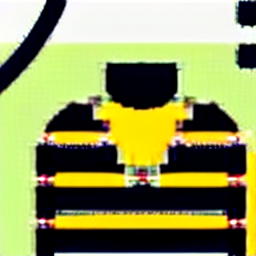

In [10]:
prompt = "a photo of a bald man have beard"

pipeline = pipeline.to("cuda")

import torch

generator = torch.Generator("cuda").manual_seed(23)

image = pipeline(prompt, generator=generator,num_inference_steps=50,height=256,width=256).images[0]
image

  0%|          | 0/50 [00:00<?, ?it/s]

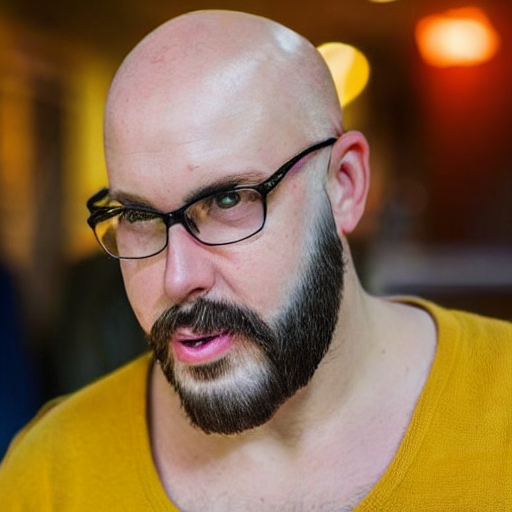

In [20]:
prompt = "a photo of a bald woman have beard"

pipeline = pipeline.to("cuda")

import torch

generator = torch.Generator("cuda").manual_seed(0)

image = pipeline(prompt,num_inference_steps=50).images[0]
image

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/model_weights/stable-diffusion-v1-5/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/model_weights/stable-diffusion-v1-5/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/model_weights/stable-diffusion-v1-5/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/model_weights/stable-diffusion-v1-5/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/50 [00:00<?, ?it/s]

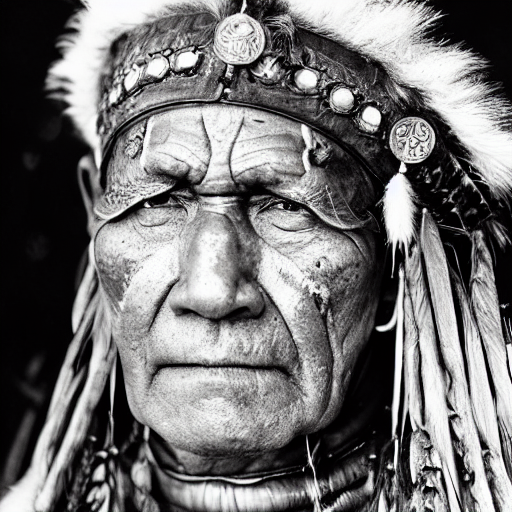

In [8]:
import torch

pipeline = DiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, use_safetensors=True)
pipeline = pipeline.to("cuda")
generator = torch.Generator("cuda").manual_seed(0)
image = pipeline(prompt, generator=generator).images[0]
image

## Test Tokenizer

In [14]:
from transformers import CLIPTextModel, CLIPTokenizer

model_id = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--sd-legacy--stable-diffusion-v1-5/snapshots/f03de327dd89b501a01da37fc5240cf4fdba85a1"
tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")

text_encoder = CLIPTextModel.from_pretrained(
    model_id, subfolder="text_encoder", revision=0
)


/home/jovyan/fcvm-data-volume/kzzr229/miniconda3/envs/mcpl/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [17]:
tokenizer.encode(['a','man','whiteman'])

[49406, 64, 723, 49407, 49407]

In [20]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--sd-legacy--stable-diffusion-v1-5/snapshots/f03de327dd89b501a01da37fc5240cf4fdba85a1"
pipe = StableDiffusionPipeline.from_pretrained(model_id,torch_dtype=torch.float16).to("cuda")

repo_id_embeds = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs/2024-10-10T13-48-22-mcpl/learned_embeds-steps-1.safetensors"
pipe.load_textual_inversion(repo_id_embeds)

prompt = "a <cat-toy> backpack"

image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]
image
#image.save("cat-backpack.png")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/home/jovyan/fcvm-data-volume/kzzr229/miniconda3/envs/mcpl/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


ValueError: Loaded state dictionary is incorrect: {'!': tensor([-1.2048e-03,  3.6799e-02,  2.2131e-02, -4.2083e-03, -1.3002e-02,
        -7.4355e-03, -9.0554e-03, -1.9786e-02,  3.2620e-02, -1.8120e-02,
         2.6730e-02, -2.0350e-02, -5.2847e-03,  1.4118e-02,  3.1785e-02,
        -3.7175e-02, -1.9553e-02,  3.2804e-03,  1.0931e-02, -6.9278e-04,
         3.3527e-02, -7.6881e-03, -4.0458e-03,  1.2430e-02,  1.2099e-02,
         2.1324e-02,  3.1349e-03, -2.2648e-03,  4.3568e-02, -5.1243e-03,
         1.4949e-03, -1.0554e-02, -2.2740e-02,  1.0705e-04,  1.2310e-02,
        -4.9703e-03, -5.4353e-03, -3.4280e-03, -1.9446e-02, -6.9566e-03,
         6.9449e-03, -1.3735e-02,  4.5183e-03,  1.3244e-02,  6.9373e-03,
        -1.6166e-03, -1.1483e-03, -1.6647e-02,  1.7757e-02, -1.7406e-02,
         9.4235e-03, -2.2281e-02,  4.3491e-03, -2.4798e-02,  3.8358e-03,
        -5.2331e-03, -1.1453e-02,  3.4177e-02, -1.4095e-02,  2.2966e-03,
        -1.1074e-02,  1.2550e-02,  5.2022e-03,  1.5407e-02,  1.0661e

In [22]:
import safetensors
safetensors.torch.load_file(repo_id_embeds).keys()

dict_keys(['!', '&', '<concept-1>', '<concept-2>', 'and', 'black', 'orange', 'red'])

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/home/jovyan/fcvm-data-volume/kzzr229/miniconda3/envs/mcpl/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  0%|          | 0/100 [00:00<?, ?it/s]

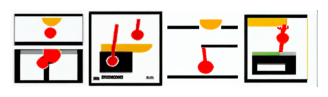

In [44]:
from diffusers import StableDiffusionPipeline,DDIMScheduler,UniPCMultistepScheduler
import torch
import matplotlib.pyplot as plt
import numpy as np

def save_images_grid(images, grid_size, save_path=None):
    """
    Save a list of images in a grid format.

    Parameters:
    - images: numpy array of shape (N, H, W, C) containing the images.
    - grid_size: tuple (grid_rows, grid_cols) for arranging images in the grid.
    - save_path: file path where the grid image will be saved.
    """
    N, H, W, C = images.shape
    grid_rows, grid_cols = grid_size

    # Check if the grid can fit all images
    assert grid_rows * grid_cols >= N, "Grid size is too small for the number of images"

    # Create an empty array for the grid image
    grid_image = np.zeros((grid_rows * H, grid_cols * W, C), dtype=images.dtype)

    # Fill the grid with images
    for idx, img in enumerate(images):
        row = idx // grid_cols
        col = idx % grid_cols
        grid_image[row * H:(row + 1) * H, col * W:(col + 1) * W, :] = img

    # Plot and save the grid image
    plt.figure(figsize=(grid_cols, grid_rows))
    plt.imshow(grid_image)
    plt.axis('off')  # Turn off axis labels
    #plt.savefig(save_path)
    #plt.close()


model_id = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--sd-legacy--stable-diffusion-v1-5/snapshots/f03de327dd89b501a01da37fc5240cf4fdba85a1"
pipe = StableDiffusionPipeline.from_pretrained(model_id,torch_dtype=torch.float16).to("cuda")
pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config
)
pipe.safety_checker = None
pipe.requires_safety_checker = False

repo_id_embeds = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs/2024-10-11T10-15-41-mcpl-all/learned_embeds-steps-3000.safetensors"
pipe.load_mcpl_inversion(repo_id_embeds)

prompt = "a photo of orange @ and red * and black & and black !"

images = pipe(prompt, num_inference_steps=100, guidance_scale=7.5,num_images_per_prompt=4).images
save_images_grid(np.stack([np.asarray(img) for img in images]),(1,4))

In [46]:
embed_name = repo_id_embeds.split('/')[-2]

'2024-10-10T21-21-57-mcpl-all'

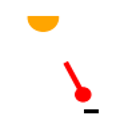

In [4]:
from PIL import Image
import PIL
image = Image.open("/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_4_concepts/pendulum/3/a_29_127_3_15.png")
image = image.resize((128, 128), resample=PIL.Image.BICUBIC)
image

In [ ]:
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from edit_modules.load_datasets_adni import load_data,load_extra_attributes

num_of_slices = 20
keep_only_screening = False
data_root = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/counterfactual_benchmark/datasets/adni/preprocessing/'
data_dir = os.path.join(data_root, 'preprocessed_data')
image_paths, attribute_dict, subject_dates_dict = load_data(data_dir, num_of_slices=num_of_slices,
                                                        split='train',
                                                        keep_only_screening=keep_only_screening)
            

load images: 100%|██████████| 447/447 [00:01<00:00, 288.48it/s]


In [18]:
from PIL import Image
import numpy as np
a= Image.open(image_paths[1])




# Convert to NumPy array
image_array = np.array(a)

# Normalize the image (scale from min-max to 0-255)
image_array = (image_array - image_array.min()) / (image_array.max() - image_array.min()) * 255

# Convert to uint8 (required for RGB conversion)
image_array = image_array.astype(np.uint8)

# Convert back to a PIL image in RGB mode
rgb_image = Image.fromarray(image_array, mode="L").convert("RGB")

In [11]:
data[1][0].shape

torch.Size([3, 128, 128])

In [4]:
from torch.utils.data import Dataset
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from edit_modules.load_celebahq import CelebAHQ

from torchvision.transforms import Resize, ToTensor, CenterCrop, Compose, ConvertImageDtype
from torchvision import transforms
import torch
image_transforms = transforms.Compose(
        [
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
)
data_dir='/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/datasets/'
#transforms = Compose([CenterCrop(150), Resize((64, 64)), ToTensor(), ConvertImageDtype(dtype=torch.float32),])
data = CelebAHQ(root=data_dir, split='train', transform=image_transforms, download=False)

In [5]:
data.attr_names

['5_o_Clock_Shadow',
 'Arched_Eyebrows',
 'Attractive',
 'Bags_Under_Eyes',
 'Bald',
 'Bangs',
 'Big_Lips',
 'Big_Nose',
 'Black_Hair',
 'Blond_Hair',
 'Blurry',
 'Brown_Hair',
 'Bushy_Eyebrows',
 'Chubby',
 'Double_Chin',
 'Eyeglasses',
 'Goatee',
 'Gray_Hair',
 'Heavy_Makeup',
 'High_Cheekbones',
 'Male',
 'Mouth_Slightly_Open',
 'Mustache',
 'Narrow_Eyes',
 'No_Beard',
 'Oval_Face',
 'Pale_Skin',
 'Pointy_Nose',
 'Receding_Hairline',
 'Rosy_Cheeks',
 'Sideburns',
 'Smiling',
 'Straight_Hair',
 'Wavy_Hair',
 'Wearing_Earrings',
 'Wearing_Hat',
 'Wearing_Lipstick',
 'Wearing_Necklace',
 'Wearing_Necktie',
 'Young']